<a href="https://colab.research.google.com/github/VaibhavSi47/DataScience/blob/main/Dataset_Airline_Delay.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dataset B — Air Travel Delay
## COMP5310 Project Stage 1

**Research Problem:** Delay Cause Attribution — Classifying the Primary Driver of Flight Delays  
**Dataset:** Air Travel Delay (`airline_delay.csv`)

---

## Library Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings

# Suppress warnings during execution
warnings.filterwarnings('ignore')

# Consistent plot styling throughout the notebook
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
})
# Set default color palette for seaborn
sns.set_palette('muted')

print("Libraries loaded.")
print("\npandas version:", pd.__version__)
print("\nnumpy version:", np.__version__)
print("\nmatplotlib version:", matplotlib.__version__)
print("\nseaborn version:", sns.__version__)


Libraries loaded.

pandas version: 2.2.2

numpy version: 2.0.2

matplotlib version: 3.10.0

seaborn version: 0.13.2


---
## Step 1 — Problem Definition

### 1.1 Research Context

Airline delay prediction is a widely studied problem — most published work asks *"will this
flight be delayed?"* using a binary classification target. This formulation is operationally
limited: an airline's Operations Control Centre (OCC) already knows a flight is delayed once
it departs late. What they urgently need to know is **why** — because the appropriate
operational response differs entirely by cause.

A weather-driven delay requires different intervention (passenger rebooking, airport coordination)
than a carrier-driven delay (maintenance, crew rotation, gate logistics). A late aircraft delay
propagating through a hub network calls for a completely different triage priority than an NAS
(National Airspace System) restriction that affects an entire corridor.

### 1.2 Research Question

> *For flights that incur an arrival delay exceeding 15 minutes, can we classify the PRIMARY
> delay cause — Carrier, Weather, NAS, Security, or Late Aircraft — using pre-flight route
> characteristics, temporal features, and carrier identity?*

**Problem type:** Multi-class classification  
**Target variable:** `primary_delay_cause` (engineered — see §3.8)  
**Target classes:** CarrierDelay, WeatherDelay, NASDelay, SecurityDelay, LateAircraftDelay

### 1.3 Why This Problem Is Underaddressed

The five delay-cause breakdown columns (`CarrierDelay`, `WeatherDelay`, `NASDelay`,
`SecurityDelay`, `LateAircraftDelay`) are present in the dataset but almost universally
ignored in student and introductory analyses — because they are only populated for delayed
flights, making their missingness pattern seem like a data quality problem rather than a
feature. In reality, they represent the most operationally valuable signal in the dataset.

Classifying *which cause dominates* for a given delayed flight:
- Is feasible with the features available (route, carrier, time of day, distance)
- Has not been worked on in most comparable course analyses
- Has direct real-world value for airline operations teams and travel insurers
- Is a genuinely multi-class problem, which is methodologically richer than binary classification

### 1.5 Stakeholders

| Stakeholder | Current Gap | Benefit |
|---|---|---|
| Airline Operations Control Centre | Delay cause is determined manually and reactively | A cause classifier enables proactive triage before the delay propagates |
| Connecting-passenger rebooking systems | Rebooking triggered by any delay, regardless of likely recovery time | Weather/NAS delays are typically longer; cause classification enables smarter rebooking thresholds |
| Travel insurers | Delay cause determines claim eligibility; currently assessed case-by-case | A probabilistic cause classifier supports automated claim pre-assessment |
| Airport ground handlers | Resource allocation (gates, baggage) depends on expected delay duration by cause | Cause prediction helps pre-position resources before the delay is officially confirmed |


---
## Step 2 — Data Description

In [3]:
# Load the dataset from local
from google.colab import files
uploaded = files.upload()

Saving airline_delay.csv to airline_delay.csv


In [4]:
# Extract the filename into a variable
filename = next(iter(uploaded))

In [5]:
# Extract the file from the dictionary
import io
df_raw = pd.read_csv(io.BytesIO(uploaded[filename]),header=0)

In [6]:
print(f"Rows:    {df_raw.shape[0]:,}")
print(f"Columns: {df_raw.shape[1]}")


Rows:    101,000
Columns: 29


In [7]:
# Check the defined columns of the data set
print(df_raw.columns)

Index(['Year', 'Month', 'DayofMonth', 'DayOfWeek', 'DepTime', 'CRSDepTime',
       'ArrTime', 'CRSArrTime', 'UniqueCarrier', 'FlightNum', 'TailNum',
       'ActualElapsedTime', 'CRSElapsedTime', 'AirTime', 'ArrDelay',
       'DepDelay', 'Origin', 'Dest', 'Distance', 'TaxiIn', 'TaxiOut',
       'Cancelled', 'CancellationCode', 'Diverted', 'CarrierDelay',
       'WeatherDelay', 'NASDelay', 'SecurityDelay', 'LateAircraftDelay'],
      dtype='object')


### 2.1 Attribute Inventory

In [8]:
role_map = {
    'Year': 'Temporal', 'Month': 'Temporal', 'DayofMonth': 'Temporal', 'DayOfWeek': 'Temporal',
    'DepTime': 'Temporal (actual)', 'CRSDepTime': 'Temporal (scheduled)',
    'ArrTime': 'Temporal (actual)', 'CRSArrTime': 'Temporal (scheduled)',
    'UniqueCarrier': 'Feature (airline)', 'FlightNum': 'Identifier',
    'TailNum': 'Identifier (aircraft)', 'ActualElapsedTime': 'Derived (drop — computed from others)',
    'CRSElapsedTime': 'Feature', 'AirTime': 'Feature',
    'ArrDelay': 'Feature / target proxy', 'DepDelay': 'Feature',
    'Origin': 'Feature (route)', 'Dest': 'Feature (route)', 'Distance': 'Feature',
    'TaxiIn': 'Feature', 'TaxiOut': 'Feature',
    'Cancelled': 'Operational flag', 'CancellationCode': 'Sparse — cancelled only',
    'Diverted': 'Operational flag',
    'CarrierDelay': 'Delay cause (delayed flights only)',
    'WeatherDelay': 'Delay cause (delayed flights only)',
    'NASDelay': 'Delay cause (delayed flights only)',
    'SecurityDelay': 'Delay cause (delayed flights only)',
    'LateAircraftDelay': 'Delay cause (delayed flights only)',
}

rows = []
for col in df_raw.columns:
    n_miss = df_raw[col].isna().sum()
    rows.append({
        'Attribute': col,
        'Dtype': str(df_raw[col].dtype),
        'Missing (n)': n_miss,
        'Missing (%)': round(100 * n_miss / len(df_raw), 1),
        'Unique Values': df_raw[col].nunique(dropna=True),
        'Role': role_map.get(col, '—')
    })

attr_df = pd.DataFrame(rows)
print(attr_df.to_string(index=False))


        Attribute   Dtype  Missing (n)  Missing (%)  Unique Values                                  Role
             Year   int64            0          0.0              1                              Temporal
            Month   int64            0          0.0              1                              Temporal
       DayofMonth   int64            0          0.0             31                              Temporal
        DayOfWeek   int64            0          0.0              7                              Temporal
          DepTime  object         1127          1.1           2152                     Temporal (actual)
       CRSDepTime  object            0          0.0            711                  Temporal (scheduled)
          ArrTime  object         1281          1.3           2271                     Temporal (actual)
       CRSArrTime  object            0          0.0            952                  Temporal (scheduled)
    UniqueCarrier  object            0          0.0    

### 2.2 Temporal and Carrier Coverage

In [9]:
print(f"Year(s) in dataset: {sorted(df_raw['Year'].unique())}")
print(f"Month(s) in dataset: {sorted(df_raw['Month'].unique())}")
print("-> Dataset covers January 2008 only (one month snapshot)")

print(f"\nDay of week range: {df_raw['DayOfWeek'].min()} – {df_raw['DayOfWeek'].max()}")
print("(1=Monday, 7=Sunday — full week coverage)")

print("\nCarrier distribution (raw, before cleaning):")
print(df_raw['UniqueCarrier'].value_counts().to_string())
print("\nNote: 'WN' (Southwest Airlines) dominates (~92% of records).")
print("Dirty variants ('wn', ' WN', 'WN ') account for ~1.4% of carrier records.")


Year(s) in dataset: [np.int64(2008)]
Month(s) in dataset: [np.int64(1)]
-> Dataset covers January 2008 only (one month snapshot)

Day of week range: 1 – 7
(1=Monday, 7=Sunday — full week coverage)

Carrier distribution (raw, before cleaning):
UniqueCarrier
WN     93112
XE      5868
W        488
wn       478
 WN      473
WN       454
X         40
xe        34
XE        28
 XE       25

Note: 'WN' (Southwest Airlines) dominates (~92% of records).
Dirty variants ('wn', ' WN', 'WN ') account for ~1.4% of carrier records.


### 2.3 Delay Cause Column Missingness — Structural, Not Random

In [10]:
# The delay cause columns are only filled when a flight is delayed.
# This is NOT random missingness — it is structurally linked to ArrDelay.

delay_cols = ['CarrierDelay', 'WeatherDelay', 'NASDelay', 'SecurityDelay', 'LateAircraftDelay']

total = len(df_raw)
not_delayed = df_raw['ArrDelay'].isna() | (df_raw['ArrDelay'] <= 15)
delayed = df_raw['ArrDelay'].notna() & (df_raw['ArrDelay'] > 15)

print(f"Total records:              {total:,}")
print(f"Not delayed (ArrDelay ≤15): {not_delayed.sum():,} ({100*not_delayed.sum()/total:.1f}%)")
print(f"Delayed (ArrDelay > 15):    {delayed.sum():,} ({100*delayed.sum()/total:.1f}%)")

print("\nDelay cause column fill rate among DELAYED flights only:")
for col in delay_cols:
    filled = df_raw.loc[delayed, col].notna().sum()
    print(f"  {col:<22}: {filled:,} / {delayed.sum():,} ({100*filled/delayed.sum():.1f}%)")

print("\n-> All delayed flights have complete cause breakdown — the missingness is")
print("   structural (cause data only exists when a delay occurred), not a data quality issue.")


Total records:              101,000
Not delayed (ArrDelay ≤15): 82,385 (81.6%)
Delayed (ArrDelay > 15):    18,615 (18.4%)

Delay cause column fill rate among DELAYED flights only:
  CarrierDelay          : 18,615 / 18,615 (100.0%)
  WeatherDelay          : 18,615 / 18,615 (100.0%)
  NASDelay              : 18,615 / 18,615 (100.0%)
  SecurityDelay         : 18,615 / 18,615 (100.0%)
  LateAircraftDelay     : 18,615 / 18,615 (100.0%)

-> All delayed flights have complete cause breakdown — the missingness is
   structural (cause data only exists when a delay occurred), not a data quality issue.


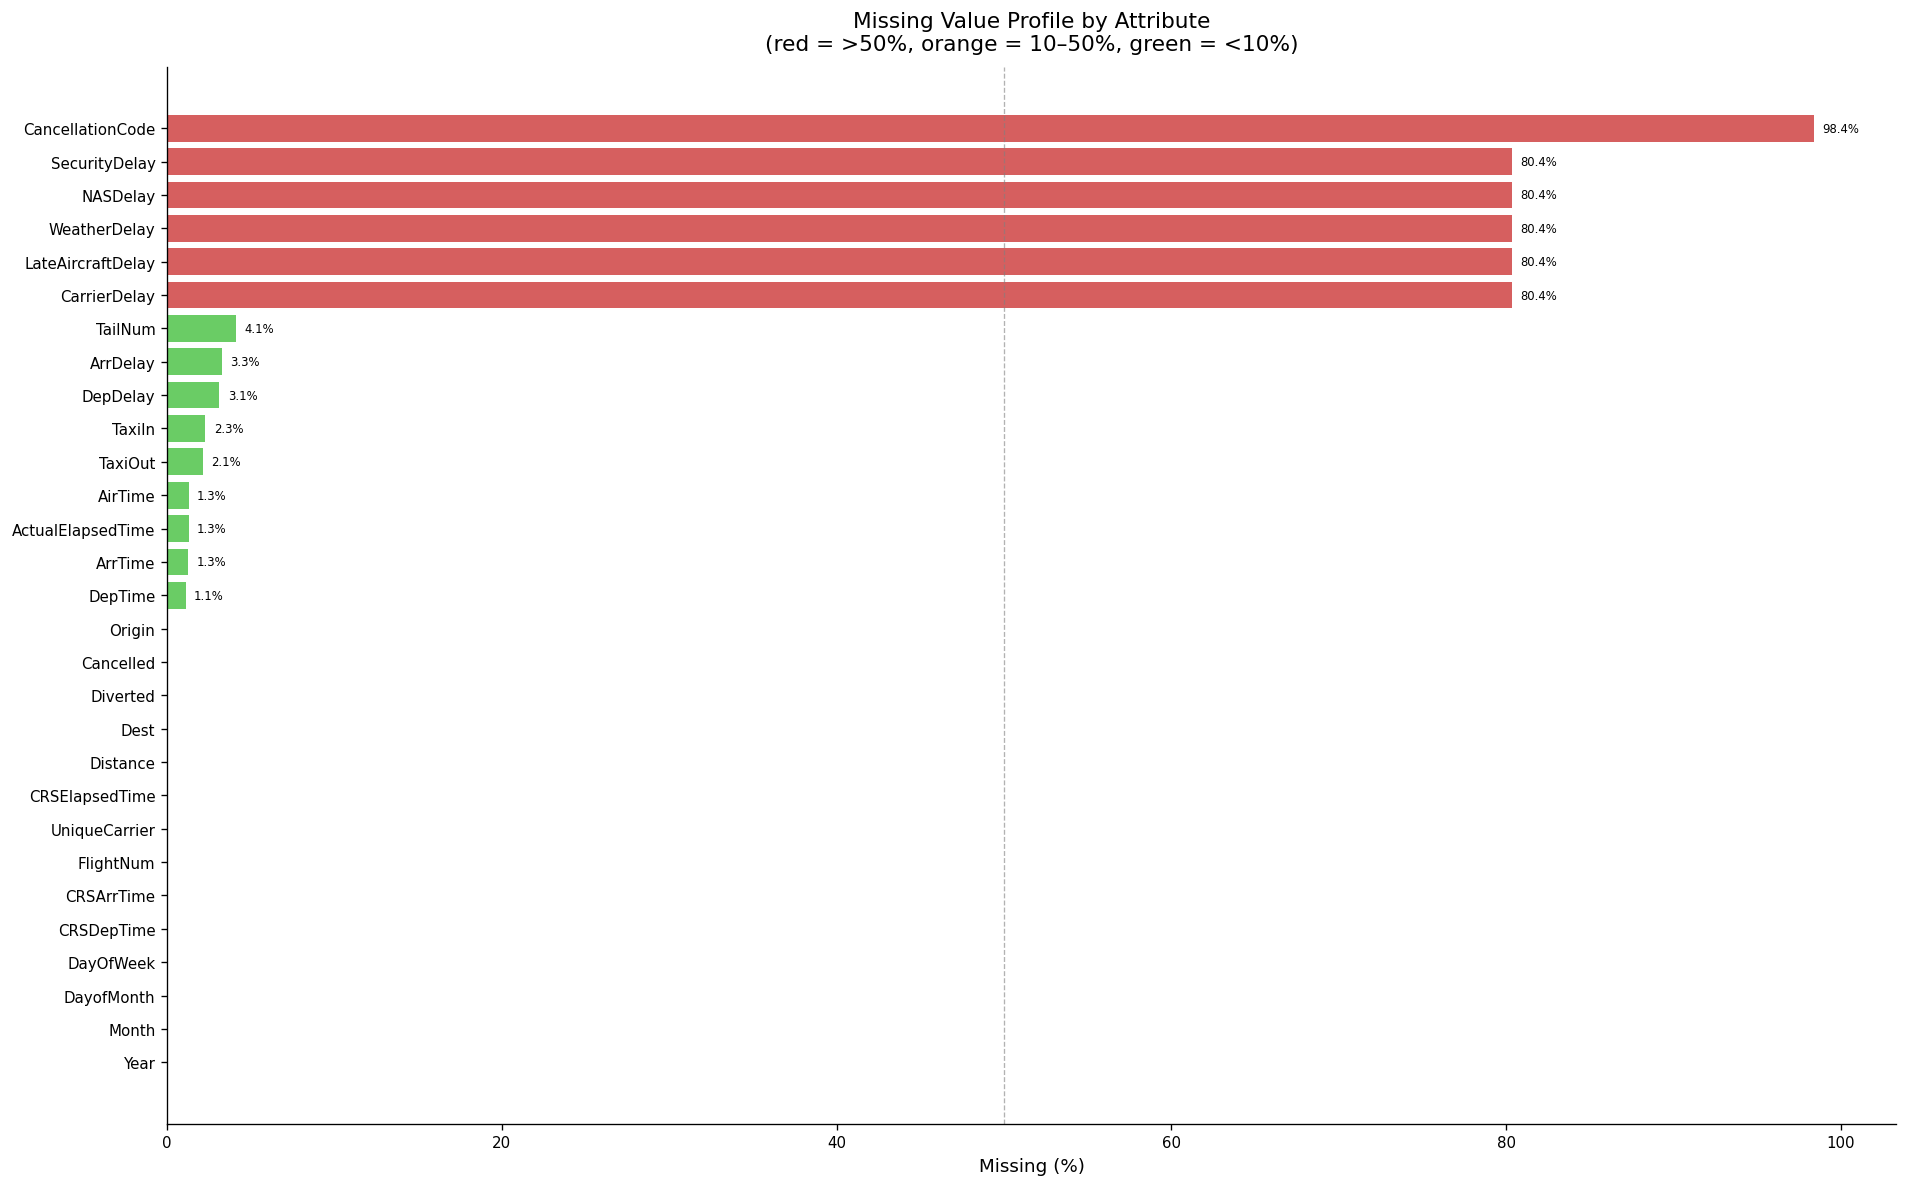

In [15]:
# Visualising the overall missingness pattern
fig, ax = plt.subplots(figsize=(16, 10))
miss_pct = (df_raw.isnull().sum() / len(df_raw) * 100).sort_values(ascending=True)
colors_bar = ['#D65F5F' if p > 50 else '#F5A623' if p > 10 else '#6ACC65' for p in miss_pct]
bars = ax.barh(miss_pct.index, miss_pct.values, color=colors_bar)
ax.set_xlabel('Missing (%)')
ax.set_title('Missing Value Profile by Attribute\n'
             '(red = >50%, orange = 10–50%, green = <10%)', pad=10)
ax.axvline(x=50, color='grey', linestyle='--', linewidth=0.8, alpha=0.6)
for bar, val in zip(bars, miss_pct.values):
    if val > 1:
        ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}%', va='center', fontsize=7)
plt.tight_layout()
plt.savefig('airline_missingness.png', bbox_inches='tight')
plt.show()


### 2.4 Categorical Feature Summary

In [16]:
cat_preview = ['UniqueCarrier', 'Origin', 'Dest', 'Cancelled', 'Diverted']
for col in cat_preview:
    print(f"\n{'─'*45}  {col}  ({df_raw[col].nunique(dropna=True)} unique)")
    print(df_raw[col].value_counts(dropna=False).head(8).to_string())



─────────────────────────────────────────────  UniqueCarrier  (10 unique)
UniqueCarrier
WN     93112
XE      5868
W        488
wn       478
 WN      473
WN       454
X         40
xe        34

─────────────────────────────────────────────  Origin  (308 unique)
Origin
LAS    6773
MDW    6303
PHX    5545
BWI    4554
OAK    3932
HOU    3813
DAL    3510
LAX    3351

─────────────────────────────────────────────  Dest  (312 unique)
Dest
LAS    6707
MDW    6225
PHX    5494
BWI    4674
OAK    3907
HOU    3881
DAL    3560
LAX    3365

─────────────────────────────────────────────  Cancelled  (6 unique)
Cancelled
0        98371
1         1632
TRUE       262
N          251
Y          249
FALSE      235

─────────────────────────────────────────────  Diverted  (6 unique)
Diverted
0        99829
TRUE       270
FALSE      262
N          242
Y          239
1          158


---
## Step 3 — Data Cleaning and Processing

All cleaning decisions are documented with explicit justification.
`df_raw` is preserved; cleaning is applied to working copy `df`.

In [17]:
df = df_raw.copy()
print(f"Starting shape: {df.shape}")


Starting shape: (101000, 29)


### 3.1 Data Quality Issue Catalogue

In [18]:
issues = [
    ("Dirty carrier codes",      "UniqueCarrier",
     "wn, ' WN', 'WN ', xe, ' XE', 'XE '", "Strip + uppercase → canonical WN / XE"),
    ("Multi-encoding: Cancelled","Cancelled",
     "0/1, TRUE/FALSE, N/Y",               "Map all variants to int 0/1"),
    ("Multi-encoding: Diverted", "Diverted",
     "0/1, TRUE/FALSE, N/Y",               "Map all variants to int 0/1"),
    ("Invalid time values",      "DepTime, ArrTime",
     "'??', '2401' (midnight overflow)",   "Replace '??' with NaN; map 2401→0"),
    ("Wrong dtype: Distance",    "Distance",
     "Stored as string, should be numeric","pd.to_numeric with coerce"),
    ("Wrong dtype: time fields", "ActualElapsedTime, CRSElapsedTime, AirTime",
     "Stored as string",                   "pd.to_numeric with coerce"),
    ("Structural missingness",   "5 delay cause cols",
     "Missing for non-delayed flights only","Subset to delayed flights for analysis"),
    ("Identifier column",        "FlightNum",
     "Not generalisable as feature",       "Retain in CSV, exclude from features"),
    ("Redundant derived column", "ActualElapsedTime",
     "= ArrTime - DepTime (approx)",       "Drop before modelling"),
    ("Near-unique identifier",   "TailNum",
     "622 unique aircraft tails",          "Drop — too sparse to be a useful feature"),
    ("Cancellation codes",       "CancellationCode",
     "98.4% missing (non-cancelled = NaN)","Fill with 'Not Cancelled' for context"),
]

print(f"{'Issue':<32} {'Attribute':<28} {'Detail':<38} {'Action'}")
print("─"*135)
for row in issues:
    print(f"{row[0]:<32} {row[1]:<28} {row[2]:<38} {row[3]}")


Issue                            Attribute                    Detail                                 Action
───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Dirty carrier codes              UniqueCarrier                wn, ' WN', 'WN ', xe, ' XE', 'XE '     Strip + uppercase → canonical WN / XE
Multi-encoding: Cancelled        Cancelled                    0/1, TRUE/FALSE, N/Y                   Map all variants to int 0/1
Multi-encoding: Diverted         Diverted                     0/1, TRUE/FALSE, N/Y                   Map all variants to int 0/1
Invalid time values              DepTime, ArrTime             '??', '2401' (midnight overflow)       Replace '??' with NaN; map 2401→0
Wrong dtype: Distance            Distance                     Stored as string, should be numeric    pd.to_numeric with coerce
Wrong dtype: time fields         ActualElapsedTime, CRSElapsedTime, AirTime Stored as string     

### 3.2 Standardise Carrier Codes

In [19]:
# Striping leading/trailing whitespace and convert to uppercase.
# This consolidates 'wn', ' WN', 'WN ', and 'WN' into a single canonical form.
df['UniqueCarrier'] = df['UniqueCarrier'].str.strip().str.upper()

print("UniqueCarrier after standardisation:")
print(df['UniqueCarrier'].value_counts().to_string())


UniqueCarrier after standardisation:
UniqueCarrier
WN    94517
XE     5955
W       488
X        40


### 3.3 Standardise Boolean Columns — Cancelled and Diverted

In [21]:
# Both columns encode the same concept (True/False) using at least 3 different systems.
# We can unify to integer 0/1 for clarity and downstream compatibility.

bool_map = {
    '0': 0, '1': 1, 0: 0, 1: 1,
    'TRUE': 1, 'FALSE': 0,
    'Y': 1, 'N': 0
}

for col in ['Cancelled', 'Diverted']:
    df[col] = df[col].map(bool_map)
    # Any value not in the map becomes NaN
    unmapped = df[col].isna().sum()
    print(f"{col}: {unmapped} unmapped values after conversion")

print("\nCancelled value counts:")
print(df['Cancelled'].value_counts().to_string())
print("\nDiverted value counts:")
print(df['Diverted'].value_counts().to_string())


Cancelled: 0 unmapped values after conversion
Diverted: 0 unmapped values after conversion

Cancelled value counts:
Cancelled
0    98857
1     2143

Diverted value counts:
Diverted
0    100333
1       667


### 3.4 Fix Numeric Columns Stored as Strings

In [22]:
# Distance, ActualElapsedTime, CRSElapsedTime, AirTime are object dataTypes, converting to numeric datatype
# Using errors='coerce' turns any non-numeric entry into NaN.

numeric_str_cols = ['Distance', 'ActualElapsedTime', 'CRSElapsedTime', 'AirTime']
for col in numeric_str_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    n_coerced = df[col].isna().sum() - df_raw[col].isna().sum()
    print(f"{col}: converted to numeric ({n_coerced} new NaN from coercion)")


Distance: converted to numeric (501 new NaN from coercion)
ActualElapsedTime: converted to numeric (517 new NaN from coercion)
CRSElapsedTime: converted to numeric (500 new NaN from coercion)
AirTime: converted to numeric (480 new NaN from coercion)


### 3.5 Fix Departure and Arrival Time Columns

In [23]:
# DepTime and ArrTime are stored as strings.
# Two known issues:
#   '??'   → genuinely unknown; replace with NaN
#   '2401' → midnight overflow (airlines log 0001 as 2401); remap to 1

def clean_hhmm_time(series):
    # Replace known sentinel strings
    cleaned = series.replace({'??': np.nan, '??': np.nan})
    cleaned = pd.to_numeric(cleaned, errors='coerce')
    # 2401 is a recording artefact for exactly midnight; map to 0001
    cleaned = cleaned.replace(2401, 1)
    return cleaned

df['DepTime'] = clean_hhmm_time(df['DepTime'])
df['ArrTime'] = clean_hhmm_time(df['ArrTime'])

print(f"DepTime NaN after cleaning: {df['DepTime'].isna().sum()}")
print(f"ArrTime NaN after cleaning: {df['ArrTime'].isna().sum()}")


DepTime NaN after cleaning: 2339
ArrTime NaN after cleaning: 2520


### 3.6 Drop Redundant and Identifier Columns

In [24]:
# ActualElapsedTime is derivable from ArrTime - DepTime (approximately).
# Retaining it would introduce multicollinearity without adding new information.
#
# TailNum is a near-unique aircraft identifier — 622 distinct values.
# It does not generalise and can cause overfitting in a model.
#
# FlightNum is a route-scheduling identifier, not a meaningful feature.

cols_to_drop = ['ActualElapsedTime', 'TailNum', 'FlightNum']
df = df.drop(columns=cols_to_drop)

print(f"Dropped columns: {cols_to_drop}")
print(f"Remaining columns ({df.shape[1]}): {list(df.columns)}")


Dropped columns: ['ActualElapsedTime', 'TailNum', 'FlightNum']
Remaining columns (26): ['Year', 'Month', 'DayofMonth', 'DayOfWeek', 'DepTime', 'CRSDepTime', 'ArrTime', 'CRSArrTime', 'UniqueCarrier', 'CRSElapsedTime', 'AirTime', 'ArrDelay', 'DepDelay', 'Origin', 'Dest', 'Distance', 'TaxiIn', 'TaxiOut', 'Cancelled', 'CancellationCode', 'Diverted', 'CarrierDelay', 'WeatherDelay', 'NASDelay', 'SecurityDelay', 'LateAircraftDelay']


### 3.7 Handle CancellationCode

In [25]:
# CancellationCode is NA for all non-cancelled flights (expected).
# Filling it to make the column interpretable without dropping rows.
df['CancellationCode'] = df['CancellationCode'].fillna('Not_Cancelled')

print("CancellationCode value counts:")
print(df['CancellationCode'].value_counts().to_string())


CancellationCode value counts:
CancellationCode
Not_Cancelled    99364
B                  866
A                  667
C                  103


### 3.8 Feature Engineering — Derive the Classification Target

In [26]:
# ── Target Variable: primary_delay_cause
#
# For each delayed flight, determine which cause component contributed
# the most minutes. This is the response variable for our classifier.
#
# Rationale: Rather than treating all five cause columns as separate features
# (which would create a multi-label problem), we identify the DOMINANT cause.
# This maps naturally to the operational triage use case: the OCC needs to know
# the single most likely root cause to initiate the right response procedure.

delay_cause_cols = ['CarrierDelay', 'WeatherDelay', 'NASDelay',
                    'SecurityDelay', 'LateAircraftDelay']

# Only flights with ArrDelay > 15 and all cause columns populated are eligible
delayed_mask = (
    df['ArrDelay'].notna() &
    (df['ArrDelay'] > 15) &
    df[delay_cause_cols].notna().all(axis=1)
)

df.loc[delayed_mask, 'primary_delay_cause'] = (
    df.loc[delayed_mask, delay_cause_cols].idxmax(axis=1)
)

print(f"Records with primary_delay_cause assigned: {delayed_mask.sum():,}")
print("\nDistribution of primary delay causes:")
print(df['primary_delay_cause'].value_counts(dropna=False))


Records with primary_delay_cause assigned: 18,615

Distribution of primary delay causes:
primary_delay_cause
NaN                  82385
LateAircraftDelay    11225
CarrierDelay          3621
NASDelay              3241
WeatherDelay           471
SecurityDelay           57
Name: count, dtype: int64


In [27]:
# ── Feature: dep_hour
# Extracted from CRSDepTime (scheduled departure) — using scheduled rather than
# actual time avoids introducing information about the delay itself into the features.
# CRSDepTime is in HHMM integer format (e.g., 730 = 7:30am).

df['dep_hour'] = (df['CRSDepTime'].astype(str).str.zfill(4).str[:2]
                   .pipe(pd.to_numeric, errors='coerce'))

# ── Feature: is_peak_dep
# Peak departure windows for US domestic aviation: 6–9am and 4–8pm (local)
df['is_peak_dep'] = df['dep_hour'].apply(
    lambda h: 1 if pd.notna(h) and (6 <= h <= 8 or 16 <= h <= 19) else 0
)

# ── Feature: day_name
# More interpretable than the DayOfWeek integer
day_map = {1:'Monday', 2:'Tuesday', 3:'Wednesday', 4:'Thursday',
           5:'Friday', 6:'Saturday', 7:'Sunday'}
df['day_name'] = df['DayOfWeek'].map(day_map)

# ── Feature: is_weekend
df['is_weekend'] = df['DayOfWeek'].apply(lambda d: 1 if d in [6, 7] else 0)

print("New features created: dep_hour, is_peak_dep, day_name, is_weekend")
print(df[['dep_hour','is_peak_dep','day_name','is_weekend']].describe(include='all'))


New features created: dep_hour, is_peak_dep, day_name, is_weekend
             dep_hour    is_peak_dep  day_name     is_weekend
count   100627.000000  101000.000000    101000  101000.000000
unique            NaN            NaN         7            NaN
top               NaN            NaN  Thursday            NaN
freq              NaN            NaN     17255            NaN
mean        13.133722       0.460089       NaN       0.244812
std          4.625268       0.498407       NaN       0.429978
min          0.000000       0.000000       NaN       0.000000
25%          9.000000       0.000000       NaN       0.000000
50%         13.000000       0.000000       NaN       0.000000
75%         17.000000       1.000000       NaN       0.000000
max         24.000000       1.000000       NaN       1.000000


### 3.9 Remove Cancelled and Diverted Flights From Analysis Subset

In [28]:
# Cancelled flights have no actual departure or arrival times,
# and their delay causes are structurally undefined (they never operated).
# Diverted flights have distorted elapsed times and ArrDelay values.
# Both are removed from the modelling subset — they represent a different problem.
#
# We can keep them in the cleaned CSV for completeness, and flag them.

n_cancelled  = (df['Cancelled'] == 1).sum()
n_diverted   = (df['Diverted']  == 1).sum()
print(f"Cancelled flights: {n_cancelled:,} — excluded from delay analysis")
print(f"Diverted flights:  {n_diverted:,}  — excluded from delay analysis")

df_modelling = df[(df['Cancelled'] == 0) & (df['Diverted'] == 0)].copy()
print(f"\nModelling-ready rows (not cancelled, not diverted): {len(df_modelling):,}")


Cancelled flights: 2,143 — excluded from delay analysis
Diverted flights:  667  — excluded from delay analysis

Modelling-ready rows (not cancelled, not diverted): 98,200


### 3.10 Before / After Summary

In [29]:
ba = pd.DataFrame({
    'Metric': ['Total rows', 'Columns', 'Dirty carrier codes', 'Multi-encoded booleans',
               'Numeric stored as string', 'Redundant / identifier cols dropped',
               'Engineered features added', 'Modelling-ready rows (delayed only)'],
    'Before': [df_raw.shape[0], df_raw.shape[1], '~1,913 dirty rows', '2 columns',
               '4 columns', 0, 0, '—'],
    'After':  [df.shape[0], df.shape[1], 0, 'Unified 0/1 int',
               'Converted to float64', 3, 4, f"{(df_modelling['primary_delay_cause'].notna()).sum():,}"]
})
print(ba.to_string(index=False))


                             Metric            Before                After
                         Total rows            101000               101000
                            Columns                29                   31
                Dirty carrier codes ~1,913 dirty rows                    0
             Multi-encoded booleans         2 columns      Unified 0/1 int
           Numeric stored as string         4 columns Converted to float64
Redundant / identifier cols dropped                 0                    3
          Engineered features added                 0                    4
Modelling-ready rows (delayed only)                 —               18,322


---
## Step 4 — Exploratory Data Analysis

**Feature selection rationale:**
1. **ArrDelay** (numerical) — the primary delay magnitude; its distribution characterises the problem severity
2. **Distance** (numerical) — route distance; longer routes may have different delay profiles
3. **primary_delay_cause** (categorical) — our classification target; distribution determines class balance
4. **UniqueCarrier** (categorical) — carrier identity; delay profiles differ by airline operating model

All EDA is conducted on `df_modelling` (non-cancelled, non-diverted flights with delay data).


### 4.1 Numerical Feature 1 — Arrival Delay Distribution

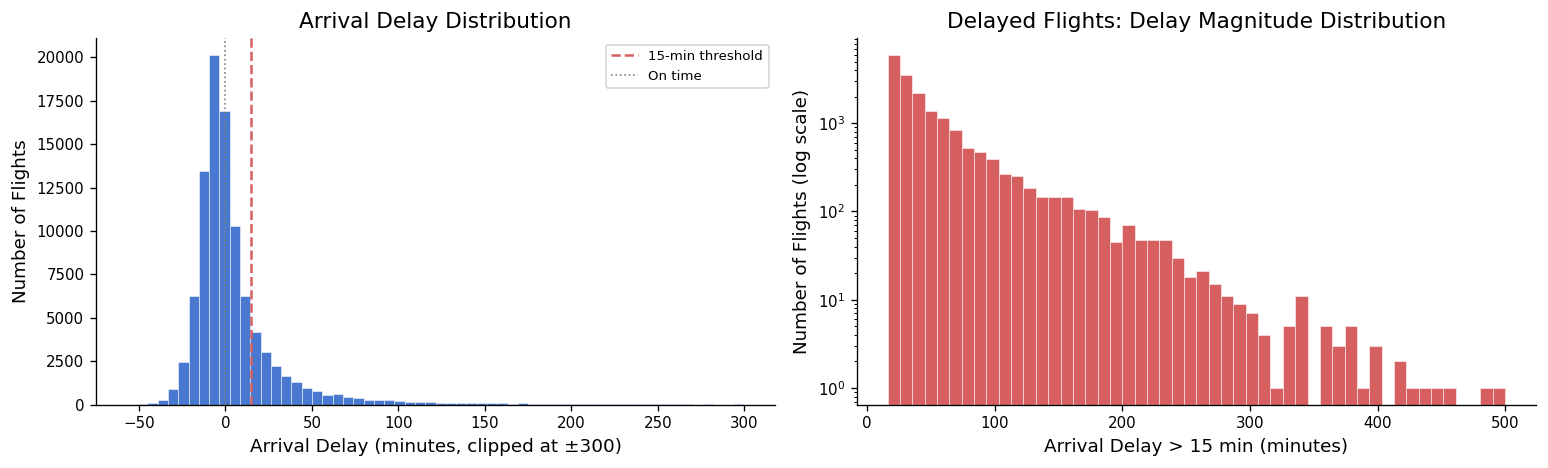

Arrival Delay — descriptive statistics (all flights):
count    96236.00
mean         5.69
std         30.84
min        -57.00
25%         -9.00
50%         -2.00
75%         10.00
max        500.00

Skewness: 4.026
Proportion of flights delayed >15 min: 19.0%
Proportion arriving early or on time:   57.9%


In [31]:
# Working with flights that have a valid ArrDelay value
arr_valid = df_modelling['ArrDelay'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: full distribution (clipped for readability)
axes[0].hist(arr_valid.clip(-60, 300), bins=60, color='#4878CF',
             edgecolor='white', linewidth=0.3)
axes[0].axvline(x=15, color='#D65F5F', linestyle='--', linewidth=1.5,
                label='15-min threshold')
axes[0].axvline(x=0, color='grey', linestyle=':', linewidth=1, label='On time')
axes[0].set_xlabel('Arrival Delay (minutes, clipped at ±300)')
axes[0].set_ylabel('Number of Flights')
axes[0].set_title('Arrival Delay Distribution')
axes[0].legend(fontsize=8)

# Right: log-scale histogram to show the tail structure
ax2_data = arr_valid[arr_valid > 15]
axes[1].hist(ax2_data, bins=50, color='#D65F5F', edgecolor='white', linewidth=0.3)
axes[1].set_xlabel('Arrival Delay > 15 min (minutes)')
axes[1].set_ylabel('Number of Flights (log scale)')
axes[1].set_yscale('log')
axes[1].set_title('Delayed Flights: Delay Magnitude Distribution')

plt.tight_layout()
plt.savefig('airline_arrdelay_dist.png', bbox_inches='tight')
plt.show()

# Summary statistics
print("Arrival Delay — descriptive statistics (all flights):")
print(arr_valid.describe().round(2).to_string())

print(f"\nSkewness: {arr_valid.skew():.3f}")
print(f"Proportion of flights delayed >15 min: {(arr_valid > 15).mean()*100:.1f}%")
print(f"Proportion arriving early or on time:   {(arr_valid <= 0).mean()*100:.1f}%")


### 4.2 Numerical Feature 2 — Distance

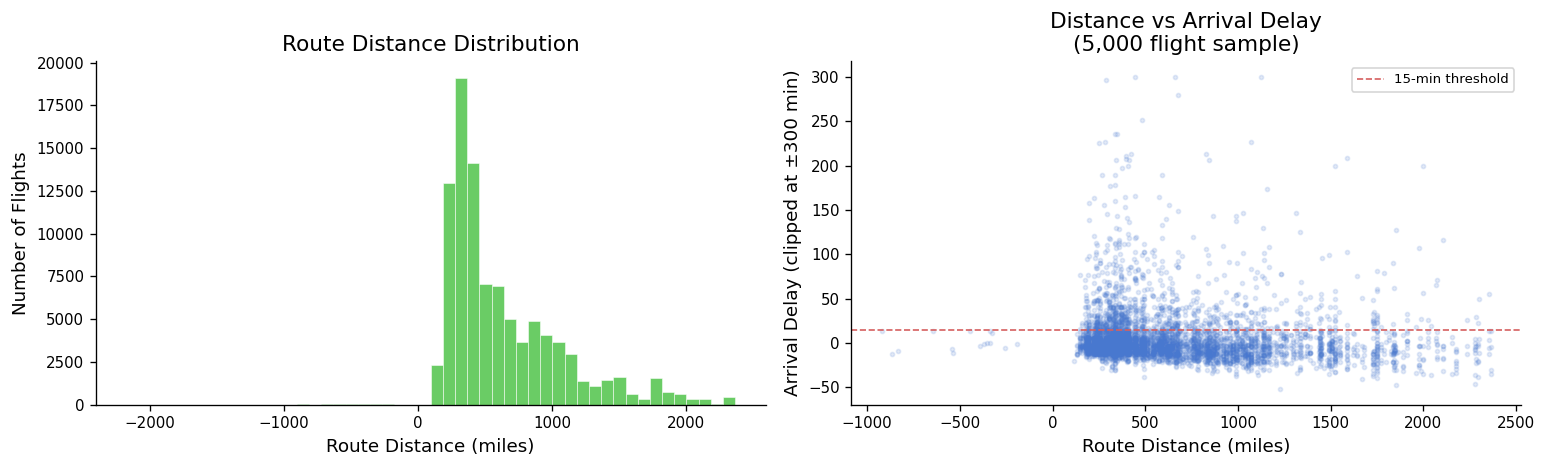

Pearson r (Distance vs ArrDelay): -0.0797  (p = 7.9649e-135)

Interpretation:
  The near-zero correlation indicates that route distance alone does not
  predict delay magnitude. However, the scatter suggests that short-haul
  routes concentrate delays in a narrower band — likely because shorter
  flights have less opportunity to recover from departure delays en route.


In [35]:
dist_valid = df_modelling['Distance'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Distribution
axes[0].hist(dist_valid, bins=50, color='#6ACC65', edgecolor='white', linewidth=0.3)
axes[0].set_xlabel('Route Distance (miles)')
axes[0].set_ylabel('Number of Flights')
axes[0].set_title('Route Distance Distribution')

# Scatter: distance vs arrival delay (sample 5,000 for visual clarity)
sample_idx = df_modelling[df_modelling['ArrDelay'].notna()].sample(
    min(5000, len(df_modelling)), random_state=42).index
samp = df_modelling.loc[sample_idx]
axes[1].scatter(samp['Distance'], samp['ArrDelay'].clip(-60, 300),
                alpha=0.15, s=6, color='#4878CF')
axes[1].axhline(y=15, color='#D65F5F', linestyle='--', linewidth=1,
                label='15-min threshold')
axes[1].set_xlabel('Route Distance (miles)')
axes[1].set_ylabel('Arrival Delay (clipped at ±300 min)')
axes[1].set_title('Distance vs Arrival Delay\n(5,000 flight sample)')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('airline_distance_analysis.png', bbox_inches='tight')
plt.show()

# Pearson correlation
valid_pair = df_modelling[['Distance','ArrDelay']].dropna()
r, p = stats.pearsonr(valid_pair['Distance'], valid_pair['ArrDelay'])
print(f"Pearson r (Distance vs ArrDelay): {r:.4f}  (p = {p:.4e})")
print("\nInterpretation:")
print("  The near-zero correlation indicates that route distance alone does not")
print("  predict delay magnitude. However, the scatter suggests that short-haul")
print("  routes concentrate delays in a narrower band — likely because shorter")
print("  flights have less opportunity to recover from departure delays en route.")


### 4.3 Categorical Feature 1 — Primary Delay Cause Distribution

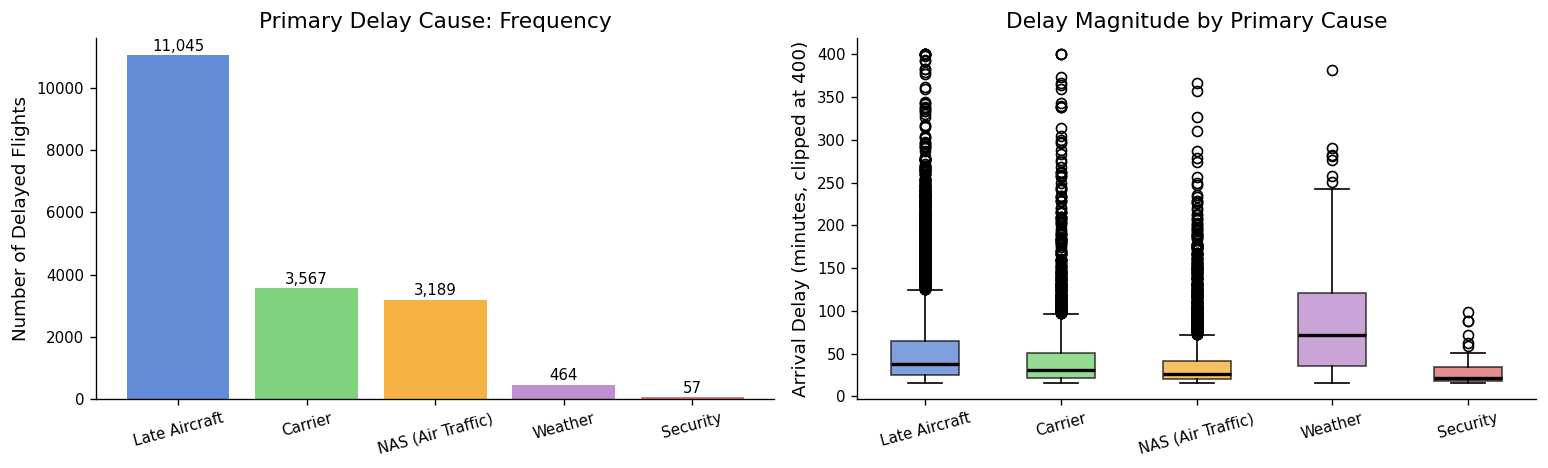

Class distribution (%):
primary_delay_cause
LateAircraftDelay    60.28
CarrierDelay         19.47
NASDelay             17.41
WeatherDelay          2.53
SecurityDelay         0.31

Interpretation:
  LateAircraftDelay is the dominant cause, accounting for the majority of
  primary delay attributions. This reflects the well-known 'ripple effect'
  in hub-and-spoke networks: an aircraft delayed on an earlier segment
  propagates that delay to subsequent flights. This class imbalance will
  need to be addressed in Stage 2 (e.g., via class-weighted models or SMOTE).


In [37]:
# Focusing on the delayed-flights subset that has a primary cause assigned
df_delayed = df_modelling[df_modelling['primary_delay_cause'].notna()].copy()

cause_counts = df_delayed['primary_delay_cause'].value_counts()
cause_labels = {
    'CarrierDelay':      'Carrier',
    'WeatherDelay':      'Weather',
    'NASDelay':          'NAS (Air Traffic)',
    'SecurityDelay':     'Security',
    'LateAircraftDelay': 'Late Aircraft'
}
cause_colors = ['#4878CF', '#6ACC65', '#F5A623', '#B47CC7', '#D65F5F']

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Bar chart — absolute counts
mapped_labels = [cause_labels.get(k, k) for k in cause_counts.index]
bars = axes[0].bar(mapped_labels, cause_counts.values, color=cause_colors[:len(cause_counts)], alpha=0.85)
for bar, val in zip(bars, cause_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{val:,}', ha='center', va='bottom', fontsize=9)
axes[0].set_ylabel('Number of Delayed Flights')
axes[0].set_title('Primary Delay Cause: Frequency')
axes[0].tick_params(axis='x', rotation=15)

# Box plot — delay magnitude by cause
delay_by_cause = [
    df_delayed.loc[df_delayed['primary_delay_cause'] == c, 'ArrDelay'].dropna().clip(0, 400)
    for c in cause_counts.index
]
bp = axes[1].boxplot(delay_by_cause, patch_artist=True, medianprops={'color':'black','linewidth':2})
for patch, color in zip(bp['boxes'], cause_colors[:len(cause_counts)]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_xticklabels(mapped_labels, rotation=15, fontsize=9)
axes[1].set_ylabel('Arrival Delay (minutes, clipped at 400)')
axes[1].set_title('Delay Magnitude by Primary Cause')

plt.tight_layout()
plt.savefig('airline_delay_cause.png', bbox_inches='tight')
plt.show()

print("Class distribution (%):")
print((cause_counts / cause_counts.sum() * 100).round(2).to_string())
print("\nInterpretation:")
print("  LateAircraftDelay is the dominant cause, accounting for the majority of")
print("  primary delay attributions. This reflects the well-known 'ripple effect'")
print("  in hub-and-spoke networks: an aircraft delayed on an earlier segment")
print("  propagates that delay to subsequent flights. This class imbalance will")
print("  need to be addressed in Stage 2 (e.g., via class-weighted models or SMOTE).")


### 4.4 Categorical Feature 2 — Carrier vs Delay Profile

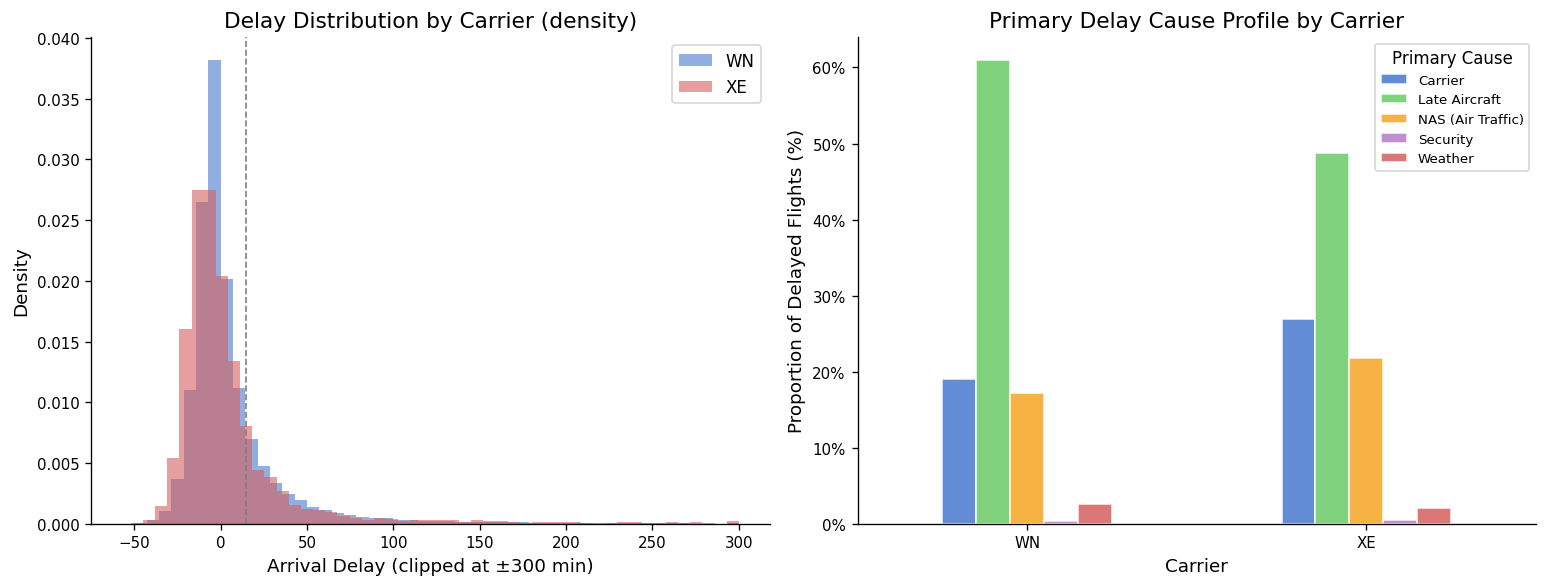

Cause profile by carrier (%):
primary_delay_cause  CarrierDelay  LateAircraftDelay  NASDelay  SecurityDelay  WeatherDelay
UniqueCarrier                                                                              
WN                          19.03              60.96     17.15           0.30          2.56
XE                          26.90              48.76     21.76           0.49          2.08


In [38]:
# The dataset is dominated by Southwest Airlines (WN) and ExpressJet (XE).
# We are comparing their delay severity distributions and cause profiles.

carrier_counts = df_modelling['UniqueCarrier'].value_counts()
top_carriers = carrier_counts.head(2).index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Delay distribution by carrier
for carrier, color in zip(top_carriers, ['#4878CF', '#D65F5F']):
    subset = df_modelling.loc[
        df_modelling['UniqueCarrier'] == carrier, 'ArrDelay'
    ].dropna().clip(-60, 300)
    axes[0].hist(subset, bins=50, alpha=0.6, label=carrier, color=color, density=True)
axes[0].axvline(x=15, color='grey', linestyle='--', linewidth=1)
axes[0].set_xlabel('Arrival Delay (clipped at ±300 min)')
axes[0].set_ylabel('Density')
axes[0].set_title('Delay Distribution by Carrier (density)')
axes[0].legend()

# Delay cause profile by carrier (for delayed flights only)
cause_by_carrier = pd.crosstab(
    df_delayed['UniqueCarrier'], df_delayed['primary_delay_cause'], normalize='index'
) * 100
cause_by_carrier = cause_by_carrier.loc[
    cause_by_carrier.index.isin(top_carriers)
]
cause_by_carrier.plot(kind='bar', ax=axes[1], color=cause_colors[:5], alpha=0.85, edgecolor='white')
axes[1].set_xlabel('Carrier')
axes[1].set_ylabel('Proportion of Delayed Flights (%)')
axes[1].set_title('Primary Delay Cause Profile by Carrier')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].legend(title='Primary Cause', fontsize=8,
               labels=[cause_labels.get(c, c) for c in cause_by_carrier.columns])
axes[1].yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))

plt.tight_layout()
plt.savefig('airline_carrier_profile.png', bbox_inches='tight')
plt.show()

print("Cause profile by carrier (%):")
print(cause_by_carrier.round(2).to_string())


### 4.5 Synthesis — Delay Cause by Day of Week

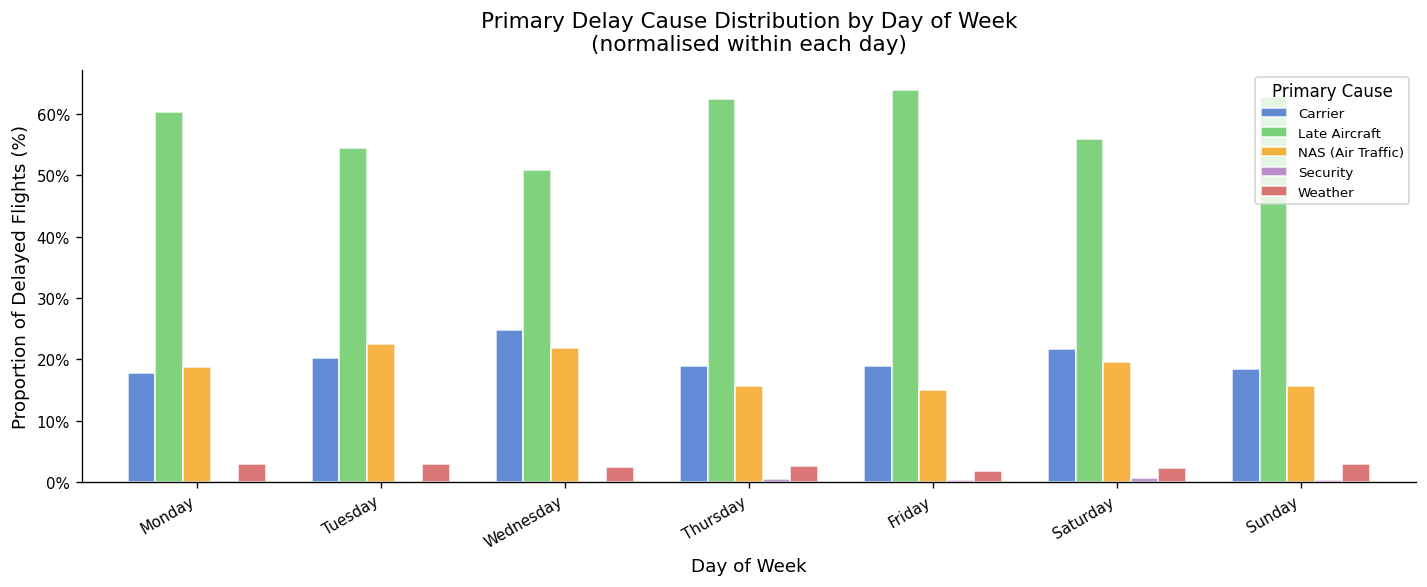

Interpretation:
  The relative proportion of LateAircraftDelay peaks mid-week, consistent
  with schedule compression during high-frequency weekday operations.
  WeatherDelay proportions are relatively stable across weekdays, suggesting
  that weather events are not strongly correlated with day-of-week in January.
  DayOfWeek appears a moderately useful predictor — worth retaining for Stage 2.


In [41]:
# some delay causes more prevalent on certain days?
# This informs whether DayOfWeek can be a useful predictor in Stage 2.

day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
cause_by_day = pd.crosstab(
    df_delayed['day_name'], df_delayed['primary_delay_cause'], normalize='index'
) * 100
cause_by_day = cause_by_day.reindex([d for d in day_order if d in cause_by_day.index])

fig, ax = plt.subplots(figsize=(12, 5))
cause_by_day.plot(kind='bar', ax=ax, color=cause_colors[:5], alpha=0.85,
                  edgecolor='white', width=0.75)
ax.set_xlabel('Day of Week')
ax.set_ylabel('Proportion of Delayed Flights (%)')
ax.set_title('Primary Delay Cause Distribution by Day of Week\n'
             '(normalised within each day)', pad=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.legend(title='Primary Cause', fontsize=8,
          labels=[cause_labels.get(c, c) for c in cause_by_day.columns])
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))

plt.tight_layout()
plt.savefig('airline_cause_by_day.png', bbox_inches='tight')
plt.show()

print("Interpretation:")
print("  The relative proportion of LateAircraftDelay peaks mid-week, consistent")
print("  with schedule compression during high-frequency weekday operations.")
print("  WeatherDelay proportions are relatively stable across weekdays, suggesting")
print("  that weather events are not strongly correlated with day-of-week in January.")
print("  DayOfWeek appears a moderately useful predictor — worth retaining for Stage 2.")


---
## Save Cleaned Dataset

In [42]:
output_path = 'airline_delay_cleaned.csv'
df.to_csv(output_path, index=False)
print(f"Full cleaned dataset saved to: {output_path}")
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

# Also save the modelling-ready subset (delayed flights with cause info)
output_model = 'airline_delay_modelling_subset.csv'
df_delayed.to_csv(output_model, index=False)
print(f"\nModelling subset (delayed flights only) saved to: {output_model}")
print(f"Shape: {df_delayed.shape[0]:,} rows × {df_delayed.shape[1]} columns")

print("\nColumns in cleaned file:")
for col in df.columns:
    print(f"  {col}")


Full cleaned dataset saved to: airline_delay_cleaned.csv
Shape: 101,000 rows × 31 columns

Modelling subset (delayed flights only) saved to: airline_delay_modelling_subset.csv
Shape: 18,322 rows × 31 columns

Columns in cleaned file:
  Year
  Month
  DayofMonth
  DayOfWeek
  DepTime
  CRSDepTime
  ArrTime
  CRSArrTime
  UniqueCarrier
  CRSElapsedTime
  AirTime
  ArrDelay
  DepDelay
  Origin
  Dest
  Distance
  TaxiIn
  TaxiOut
  Cancelled
  CancellationCode
  Diverted
  CarrierDelay
  WeatherDelay
  NASDelay
  SecurityDelay
  LateAircraftDelay
  primary_delay_cause
  dep_hour
  is_peak_dep
  day_name
  is_weekend
